# Exploratory Data Analysis — Brain Tumor Classification

Este notebook apresenta a Análise Exploratória dos Dados (Exploratory Data Analysis — EDA) realizada sobre o dataset original utilizado no desenvolvimento do sistema de classificação de tumores cerebrais baseado em Deep Learning.

A análise tem como finalidade compreender as principais características dos dados antes da realização das etapas de pré-processamento e treinamento dos modelos.

## Objectivos

- Conhecer a estrutura e organização do dataset;
- Identificar as classes presentes;
- Quantificar as imagens disponíveis para treinamento e teste;
- Analisar a distribuição das imagens entre as classes;
- Verificar as dimensões originais das imagens;
- Analisar os formatos e canais das imagens;
- Visualizar exemplos das diferentes classes;
- Identificar possíveis problemas de qualidade nos dados;
- Verificar a existência de imagens duplicadas;
- Extrair informações que possam orientar as etapas posteriores de pré-processamento e treinamento.

In [2]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

## 2. Definição do caminho do dataset

A análise será realizada sobre os dados originais, antes da sua conversão para o formato `.npz`.

O dataset apresenta a seguinte estrutura:

```text
dataset/
└── classification/
    ├── Training/
    │   ├── glioma/
    │   ├── meningioma/
    │   ├── notumor/
    │   └── pituitary/
    │
    └── Testing/
        ├── glioma/
        ├── meningioma/
        ├── notumor/
        └── pituitary/

In [5]:


DATASET_DIR = Path("../dataset/classification")

TRAIN_DIR = DATASET_DIR / "Training"
TEST_DIR = DATASET_DIR / "Testing"

print(f"Dataset: {DATASET_DIR.resolve()}")
print(f"Training: {TRAIN_DIR.resolve()}")
print(f"Testing: {TEST_DIR.resolve()}")

Dataset: E:\brain-tumor-classification-segmentation\dataset\classification
Training: E:\brain-tumor-classification-segmentation\dataset\classification\Training
Testing: E:\brain-tumor-classification-segmentation\dataset\classification\Testing


## 3. Análise da estrutura do dataset

O dataset está organizado de acordo com a classe a que cada imagem pertence. Desta forma, o nome do directório pai de cada imagem representa implicitamente o seu rótulo.

Esta organização permite identificar automaticamente as classes sem a necessidade de um ficheiro CSV adicional.

In [66]:
class_names = sorted(
    [
        directory.name
        for directory in TRAIN_DIR.iterdir()
        if directory.is_dir()
    ]
)

print("Classes encontradas:")

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Classes encontradas:
0: glioma
1: meningioma
2: notumor
3: pituitary


In [67]:
print("TRAINING")

for class_name in class_names:
    class_dir = TRAIN_DIR / class_name
    print(f"{class_name}: {class_dir.exists()}")

print("\nTESTING")

for class_name in class_names:
    class_dir = TEST_DIR / class_name
    print(f"{class_name}: {(TEST_DIR / class_name).exists()}")

TRAINING
glioma: True
meningioma: True
notumor: True
pituitary: True

TESTING
glioma: True
meningioma: True
notumor: True
pituitary: True


## 4. Contagem das imagens

Nesta etapa é contabilizado o número de imagens existentes em cada classe nos conjuntos de treinamento e teste.

A quantidade de imagens por classe é uma informação fundamental para avaliar a composição do dataset e verificar se existe algum desequilíbrio entre as classes.

In [11]:
VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}
def count_images(directory):
    count = 0

    for file in directory.iterdir():
        if file.is_file() and file.suffix.lower() in VALID_EXTENSIONS:
            count += 1

    return count


train_counts = {}
test_counts = {}

for class_name in class_names:
    train_counts[class_name] = count_images(
        TRAIN_DIR / class_name
    )

    test_counts[class_name] = count_images(
        TEST_DIR / class_name
    )

print("Training:")
for class_name, count in train_counts.items():
    print(f"{class_name:<12}: {count}")

print("\nTesting:")
for class_name, count in test_counts.items():
    print(f"{class_name:<12}: {count}")
    
    
total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
total_images = total_train + total_test

print(f"\nTotal de imagens de Training: {total_train}")
print(f"Total de imagens de Testing:  {total_test}")
print(f"Total de imagens:             {total_images}")

Training:
glioma      : 1321
meningioma  : 1339
notumor     : 1595
pituitary   : 1457

Testing:
glioma      : 300
meningioma  : 306
notumor     : 405
pituitary   : 300

Total de imagens de Training: 5712
Total de imagens de Testing:  1311
Total de imagens:             7023


## 5. Distribuição das classes

A distribuição das classes permite verificar se o número de imagens é aproximadamente uniforme entre as diferentes categorias.

Um dataset significativamente desequilibrado pode influenciar o processo de aprendizagem e, posteriormente, a interpretação das métricas de avaliação dos modelos.

In [12]:
distribution = pd.DataFrame(
    {
        "Training": train_counts,
        "Testing": test_counts
    }
)

distribution

,Training,Testing
glioma,1321,300
meningioma,1339,306
notumor,1595,405
pituitary,1457,300


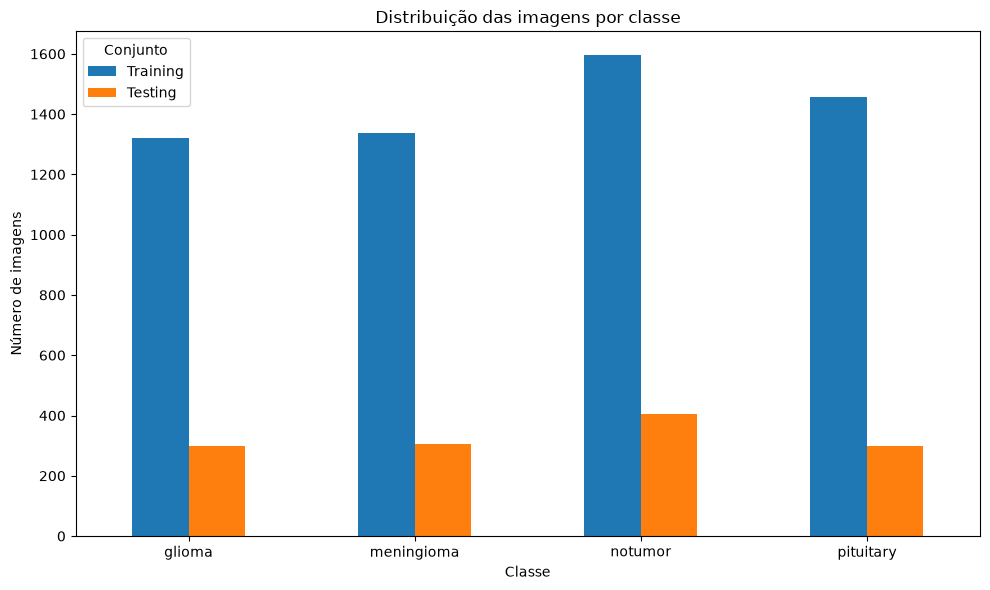

In [13]:
distribution[["Training", "Testing"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribuição das imagens por classe")
plt.xlabel("Classe")
plt.ylabel("Número de imagens")
plt.xticks(rotation=0)
plt.legend(title="Conjunto")

plt.tight_layout()
plt.show()

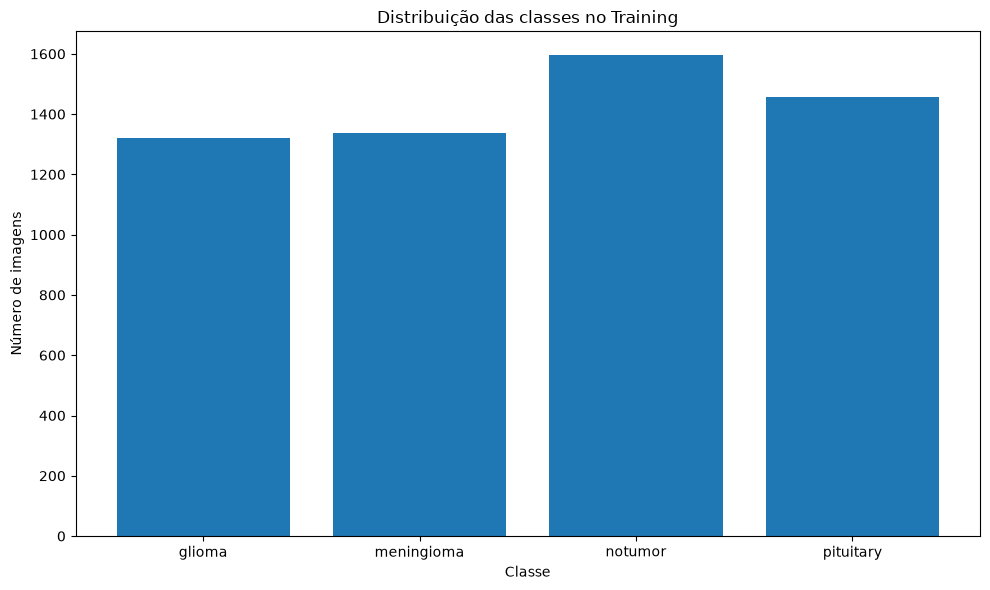

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    train_counts.keys(),
    train_counts.values()
)

plt.title("Distribuição das classes no Training")
plt.xlabel("Classe")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

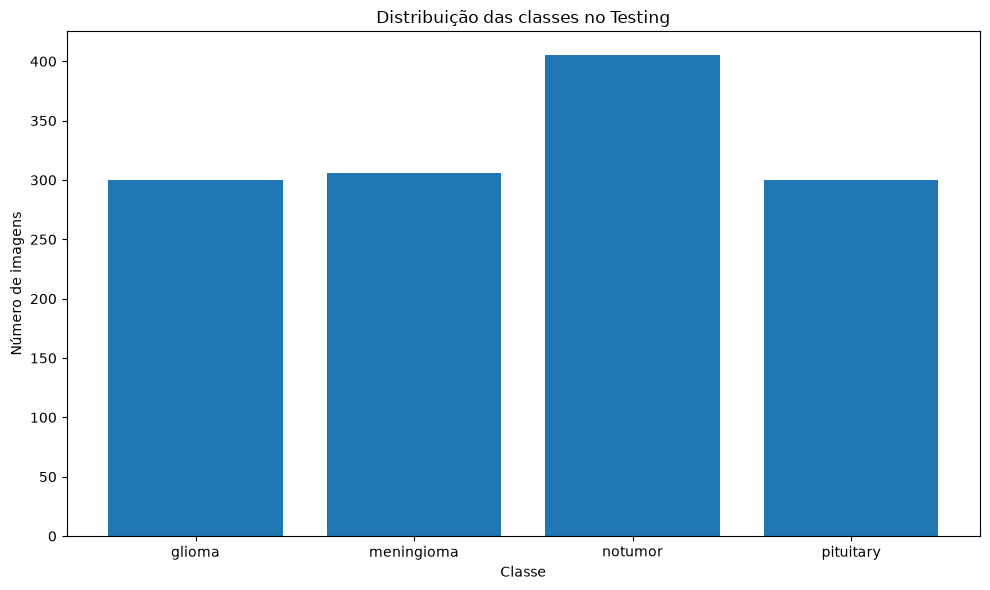

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    test_counts.keys(),
    test_counts.values()
)

plt.title("Distribuição das classes no Testing")
plt.xlabel("Classe")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

## 6. Análise dos formatos das imagens

Nesta etapa são identificados os formatos de ficheiro utilizados pelas imagens do dataset original.

Esta análise permite verificar a heterogeneidade dos dados antes do processo de preparação.

In [16]:
def collect_image_paths(directory):
    return sorted(
        [
            file
            for file in directory.rglob("*")
            if file.is_file()
            and file.suffix.lower() in VALID_EXTENSIONS
        ]
    )

In [17]:
train_paths = collect_image_paths(TRAIN_DIR)
test_paths = collect_image_paths(TEST_DIR)

all_paths = train_paths + test_paths

print(f"Imagens Training: {len(train_paths)}")
print(f"Imagens Testing:  {len(test_paths)}")
print(f"Total:            {len(all_paths)}")

Imagens Training: 5712
Imagens Testing:  1311
Total:            7023


In [18]:
extensions = Counter(
    path.suffix.lower()
    for path in all_paths
)

extension_df = pd.DataFrame(
    extensions.items(),
    columns=["Extension", "Count"]
).sort_values(
    "Count",
    ascending=False
)

extension_df

,Extension,Count
0,.jpg,7023


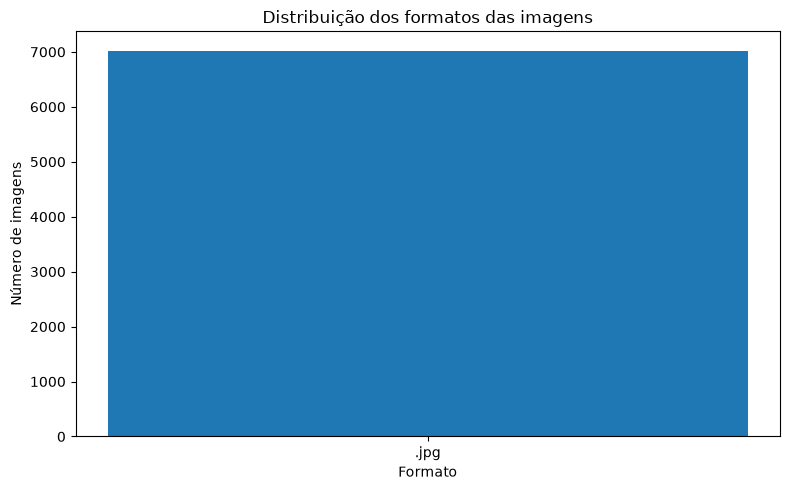

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    extension_df["Extension"],
    extension_df["Count"]
)

plt.title("Distribuição dos formatos das imagens")
plt.xlabel("Formato")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

## 7. Análise das dimensões das imagens

As imagens originais podem apresentar diferentes dimensões. Esta característica é relevante porque os modelos de Deep Learning normalmente requerem uma dimensão de entrada uniforme.

Nesta etapa são analisadas as dimensões antes do redimensionamento realizado posteriormente durante a preparação dos dados.

In [21]:
def get_image_metadata(image_path):
    try:
        with Image.open(image_path) as image:
            return {
                "path": str(image_path),
                "width": image.width,
                "height": image.height,
                "mode": image.mode,
                "format": image.format,
                "channels": len(image.getbands()),
                "valid": True,
                "error": None
            }

    except Exception as error:
        return {
            "path": str(image_path),
            "width": None,
            "height": None,
            "mode": None,
            "format": None,
            "channels": None,
            "valid": False,
            "error": str(error)
        }

In [22]:
def build_metadata(split_dir, split_name):
    rows = []

    for class_dir in sorted(
        directory
        for directory in split_dir.iterdir()
        if directory.is_dir()
    ):
        class_name = class_dir.name

        image_paths = [
            file
            for file in class_dir.iterdir()
            if file.is_file()
            and file.suffix.lower() in VALID_EXTENSIONS
        ]

        for image_path in image_paths:
            metadata = get_image_metadata(image_path)

            rows.append(
                {
                    "split": split_name,
                    "class": class_name,
                    **metadata
                }
            )

    return rows

In [23]:
metadata = (
    build_metadata(TRAIN_DIR, "Training")
    + build_metadata(TEST_DIR, "Testing")
)

metadata_df = pd.DataFrame(metadata)

metadata_df.head()

,split,class,path,width,height,mode,format,channels,valid,error
0,Training,glioma,..\dataset\classification\Training\glioma\enh_...,512,512,L,JPEG,1,True,None
1,Training,glioma,..\dataset\classification\Training\glioma\enh_...,512,512,L,JPEG,1,True,None
2,Training,glioma,..\dataset\classification\Training\glioma\enh_...,512,512,L,JPEG,1,True,None
3,Training,glioma,..\dataset\classification\Training\glioma\enh_...,512,512,L,JPEG,1,True,None
4,Training,glioma,..\dataset\classification\Training\glioma\enh_...,512,512,L,JPEG,1,True,None


In [24]:
print("Total de imagens:", len(metadata_df))
print(
    "Imagens válidas:",
    metadata_df["valid"].sum()
)
print(
    "Imagens inválidas:",
    (~metadata_df["valid"]).sum()
)

Total de imagens: 7023
Imagens válidas: 7023
Imagens inválidas: 0


In [37]:
dimension_counts = (
    metadata_df[metadata_df["valid"]]
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

dimension_counts.head(20)

,width,height,count
324,512,512,4742
89,225,225,332
348,630,630,90
149,236,236,81
21,201,251,58
99,228,221,51
109,232,217,50
210,300,168,49
291,442,442,46
0,150,198,44


In [38]:
metadata_df[
    metadata_df["valid"]
][["width", "height"]].describe()

,width,height
count,7023.000000,7023.000000
mean,445.891499,448.346860
std,132.328035,126.282922
min,150.000000,168.000000
25%,393.000000,403.500000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1920.000000,1446.000000


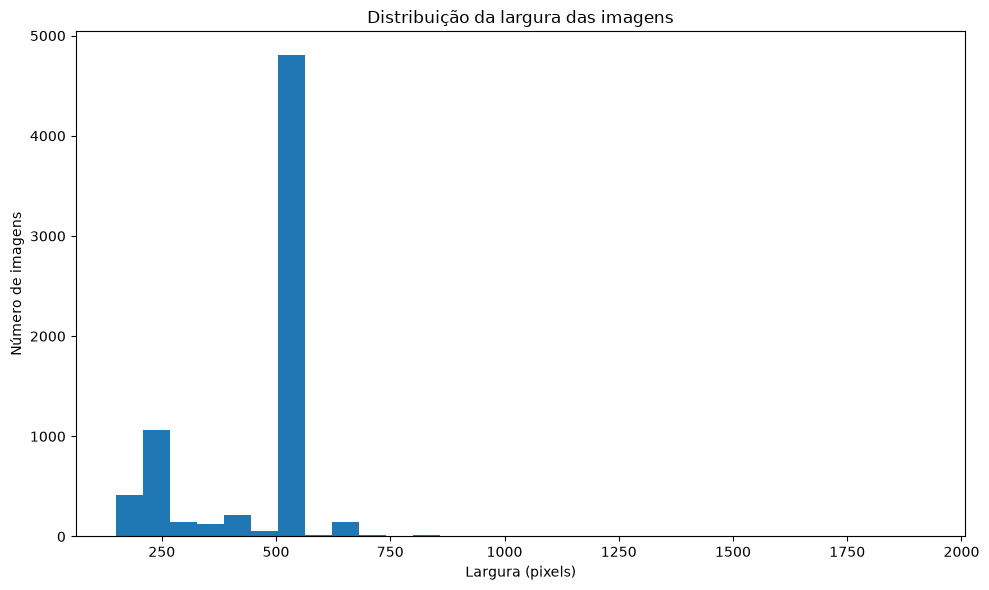

In [39]:
plt.figure(figsize=(10, 6))

plt.hist(
    metadata_df.loc[
        metadata_df["valid"],
        "width"
    ],
    bins=30
)

plt.title("Distribuição da largura das imagens")
plt.xlabel("Largura (pixels)")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

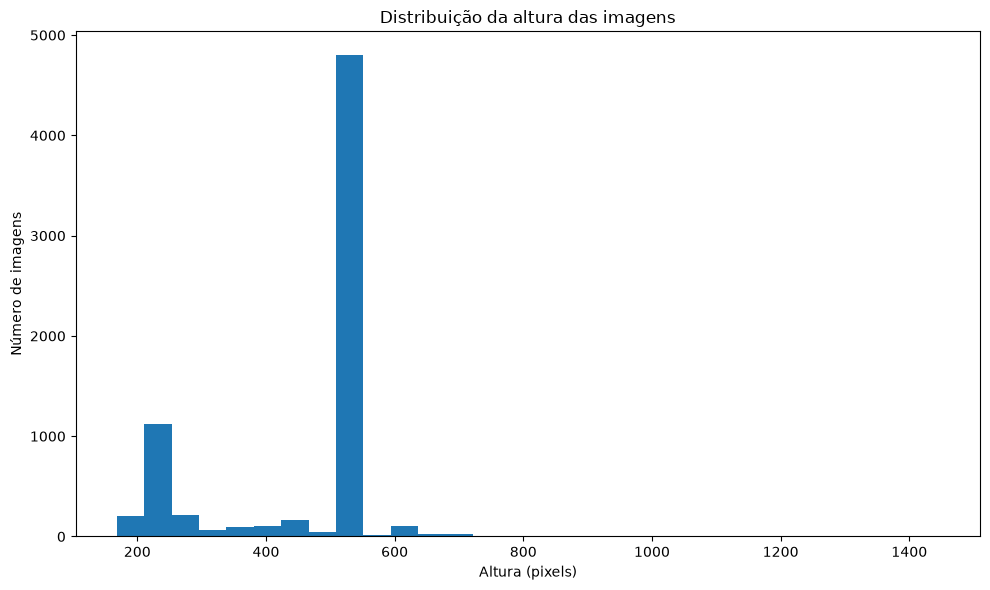

In [40]:
plt.figure(figsize=(10, 6))

plt.hist(
    metadata_df.loc[
        metadata_df["valid"],
        "height"
    ],
    bins=30
)

plt.title("Distribuição da altura das imagens")
plt.xlabel("Altura (pixels)")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

## 8. Proporção das imagens

Além da largura e altura, é importante verificar a proporção entre essas duas dimensões.

Uma grande variação na proporção pode indicar que as imagens apresentam diferentes enquadramentos ou formatos.

In [41]:
valid_metadata = metadata_df[
    metadata_df["valid"]
].copy()

valid_metadata["aspect_ratio"] = (
    valid_metadata["width"]
    / valid_metadata["height"]
)

valid_metadata["aspect_ratio"].describe()

count    7023.000000
mean        0.994010
std         0.112787
min         0.644809
25%         1.000000
50%         1.000000
75%         1.000000
max         1.785714
Name: aspect_ratio, dtype: float64

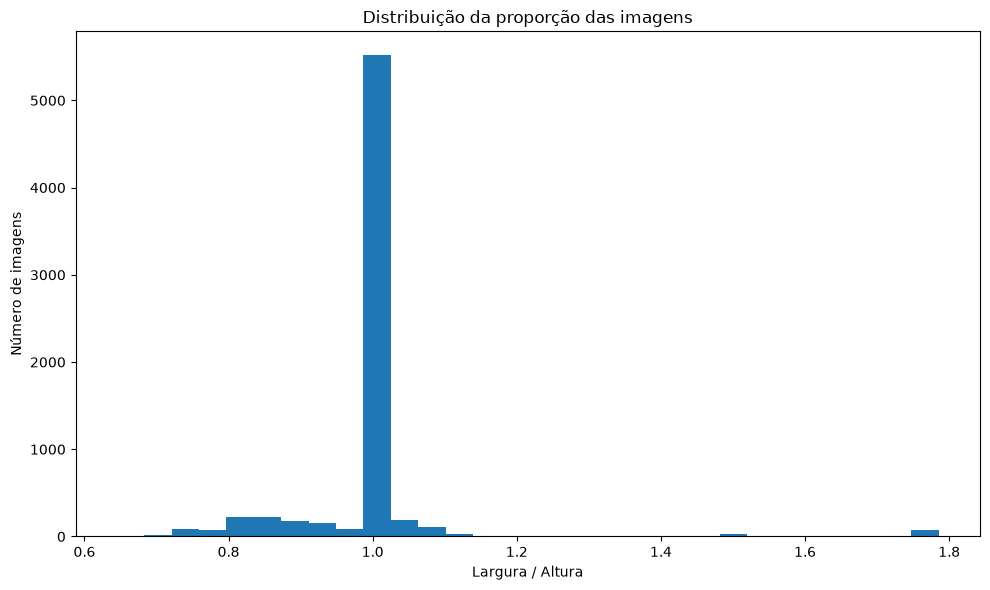

In [42]:
plt.figure(figsize=(10, 6))

plt.hist(
    valid_metadata["aspect_ratio"],
    bins=30
)

plt.title("Distribuição da proporção das imagens")
plt.xlabel("Largura / Altura")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

## 9. Análise dos canais e modos de cor

Nesta etapa são analisados os modos de cor das imagens originais.

A informação é relevante porque, durante o pré-processamento, as imagens serão convertidas para RGB para garantir uma representação uniforme com três canais.

In [43]:
mode_distribution = (
    valid_metadata["mode"]
    .value_counts()
)

mode_distribution

mode
L    7023
Name: count, dtype: int64

In [44]:
channel_distribution = (
    valid_metadata["channels"]
    .value_counts()
    .sort_index()
)

channel_distribution

channels
1    7023
Name: count, dtype: int64

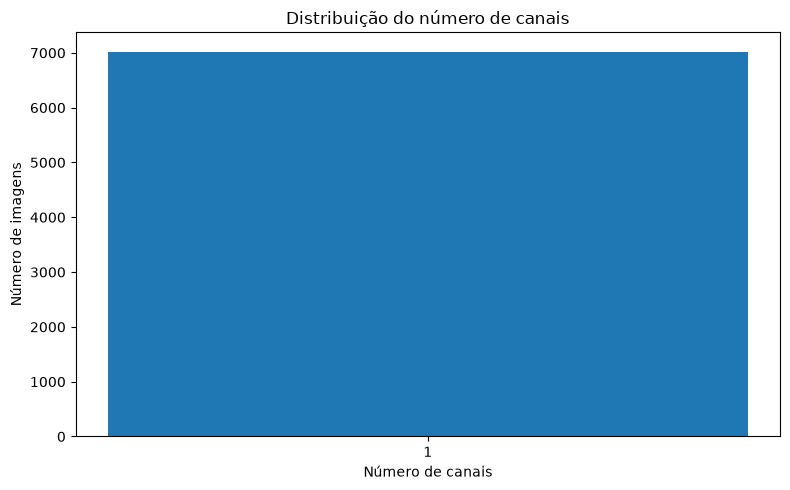

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_distribution.index.astype(str),
    channel_distribution.values
)

plt.title("Distribuição do número de canais")
plt.xlabel("Número de canais")
plt.ylabel("Número de imagens")

plt.tight_layout()
plt.show()

## 10. Visualização das imagens

A análise quantitativa deve ser complementada por uma análise visual.

Nesta etapa são apresentados exemplos das imagens pertencentes às diferentes classes, permitindo observar a variabilidade visual existente no dataset.

In [46]:
import random

random.seed(42)

def get_class_images(split_dir, class_name):
    class_dir = split_dir / class_name

    return [
        file
        for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in VALID_EXTENSIONS
    ]

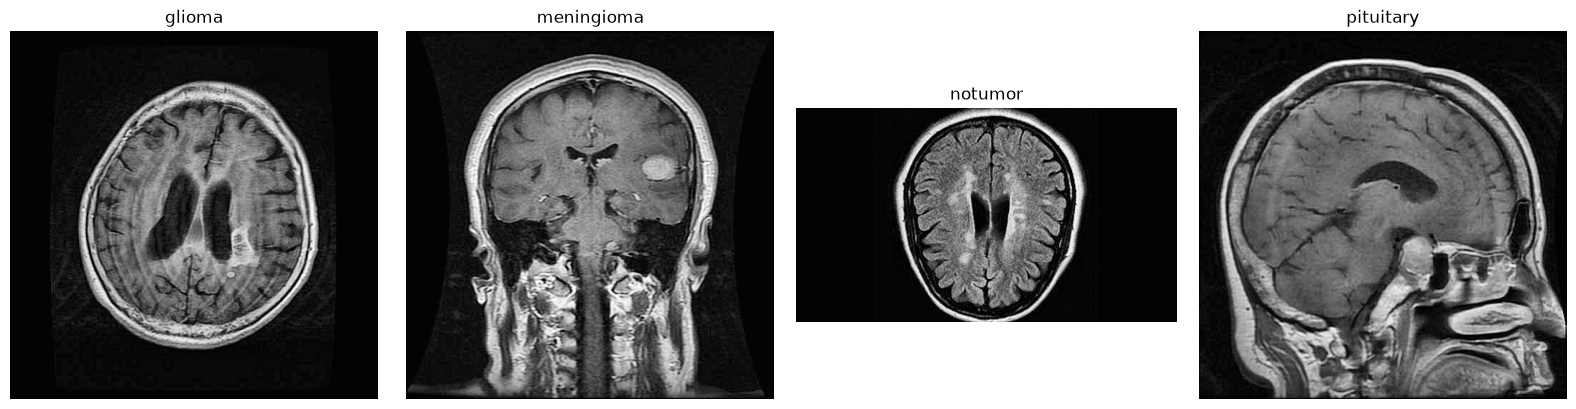

In [51]:
fig, axes = plt.subplots(
    1,
    len(class_names),
    figsize=(16, 4)
)

for ax, class_name in zip(axes, class_names):

    image_paths = get_class_images(
        TRAIN_DIR,
        class_name
    )

    image_path = random.choice(image_paths)

    with Image.open(image_path) as image:
        ax.imshow(image, cmap="gray")

    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

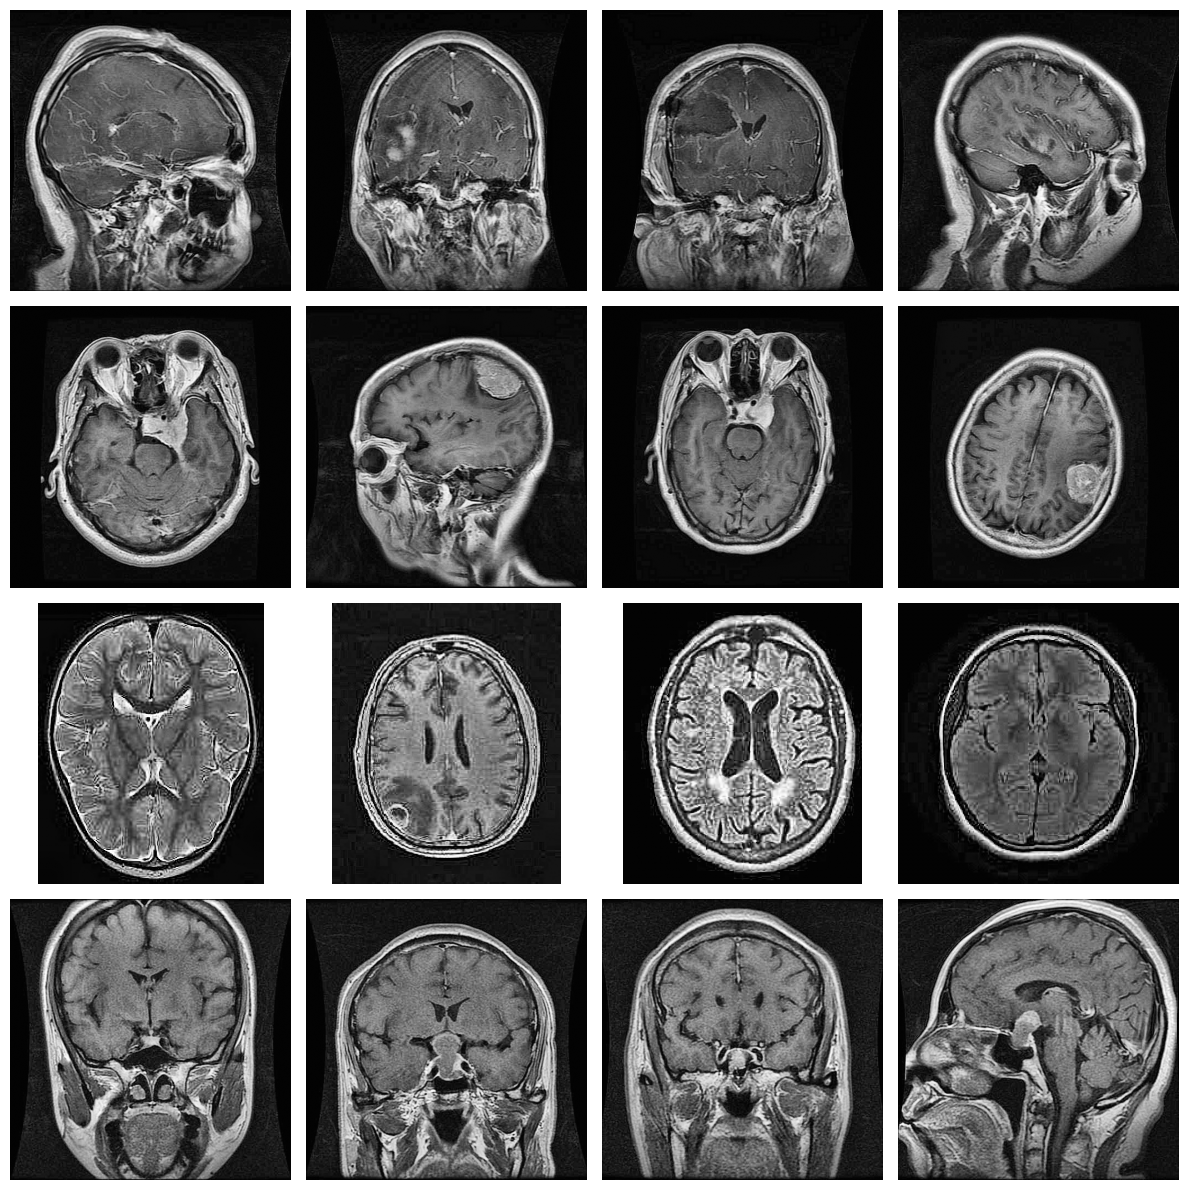

In [52]:
images_per_class = 4

fig, axes = plt.subplots(
    len(class_names),
    images_per_class,
    figsize=(12, 12)
)

for row, class_name in enumerate(class_names):

    image_paths = get_class_images(
        TRAIN_DIR,
        class_name
    )

    selected_images = random.sample(
        image_paths,
        min(images_per_class, len(image_paths))
    )

    for col in range(images_per_class):

        ax = axes[row, col]
        ax.axis("off")

        if col < len(selected_images):

            with Image.open(selected_images[col]) as image:
                ax.imshow(image, cmap="gray")

            if col == 0:
                ax.set_ylabel(
                    class_name,
                    fontsize=12
                )

plt.tight_layout()
plt.show()

## 11. Verificação de imagens inválidas

Durante a análise exploratória é importante verificar se existem ficheiros que não podem ser correctamente abertos ou interpretados como imagens.

Esses ficheiros podem provocar erros durante as etapas posteriores de preparação e treinamento.

In [49]:
invalid_images = metadata_df[
    ~metadata_df["valid"]
]

if invalid_images.empty:
    print("Não foram encontradas imagens inválidas.")
else:
    print(
        f"Foram encontradas {len(invalid_images)} imagens inválidas."
    )

    display(
        invalid_images[
            [
                "split",
                "class",
                "path",
                "error"
            ]
        ]
    )

Não foram encontradas imagens inválidas.


## 12. Verificação de duplicados

A existência de imagens duplicadas deve ser considerada porque pode influenciar a avaliação dos modelos.

Nesta análise será utilizado o hash SHA-256 para identificar ficheiros binariamente idênticos.

In [53]:
import hashlib

def calculate_hash(file_path):
    hash_sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(4096),
            b""
        ):
            hash_sha256.update(block)

    return hash_sha256.hexdigest()

In [54]:
hashes = []

for path in metadata_df["path"]:

    try:
        file_hash = calculate_hash(path)
    except Exception:
        file_hash = None

    hashes.append(file_hash)

metadata_df["sha256"] = hashes

In [56]:
duplicate_groups = (
    metadata_df
    .dropna(subset=["sha256"])
    .groupby("sha256")
    .filter(lambda group: len(group) > 1)
)

if duplicate_groups.empty:
    print("Não foram encontrados ficheiros duplicados.")
else:
    print(
        f"Foram encontrados "
        f"{duplicate_groups['sha256'].nunique()} grupos de duplicados."
    )

    display(
        duplicate_groups[
            [
                "split",
                "class",
                "path",
                "sha256"
            ]
        ].sort_values("sha256")
    )

Foram encontrados 300 grupos de duplicados.


,split,class,path,sha256
1578,Training,meningioma,..\dataset\classification\Training\meningioma\...,0093201c8044b1c03b5bb42b5821f7971993636de9812c...
6091,Testing,meningioma,..\dataset\classification\Testing\meningioma\e...,0093201c8044b1c03b5bb42b5821f7971993636de9812c...
2880,Training,notumor,..\dataset\classification\Training\notumor\enh...,01cf5277aa7f52c29a559cb9fa55aa727891e04e8b1037...
3743,Training,notumor,..\dataset\classification\Training\notumor\enh...,01cf5277aa7f52c29a559cb9fa55aa727891e04e8b1037...
6037,Testing,meningioma,..\dataset\classification\Testing\meningioma\e...,0251f686d9018d509ff9c0446e686217e71ad39337a941...
...,...,...,...,...
6070,Testing,meningioma,..\dataset\classification\Testing\meningioma\e...,ff31b1c0a364025881d7a18e07bcd3b5a61e49ab89613e...
6359,Testing,notumor,..\dataset\classification\Testing\notumor\enh_...,ff33c4c7300aec02e6062a8922cffb397fbbb2ce5ff396...
2806,Training,notumor,..\dataset\classification\Training\notumor\enh...,ff33c4c7300aec02e6062a8922cffb397fbbb2ce5ff396...
4414,Training,pituitary,..\dataset\classification\Training\pituitary\e...,ff53eaddb51322b5f6225c7c7bd8d749c392108e516f26...


In [58]:
def show_duplicate_examples(
    duplicate_df,
    max_groups=5
):
    """
    Visualiza exemplos de grupos de imagens duplicadas.
    """

    duplicate_hashes = (
        duplicate_df["sha256"]
        .drop_duplicates()
        .head(max_groups)
    )

    if len(duplicate_hashes) == 0:
        print("Não existem duplicados para visualizar.")
        return

    for hash_value in duplicate_hashes:

        group = duplicate_df[
            duplicate_df["sha256"] == hash_value
        ]

        image_paths = group["path"].tolist()

        fig, axes = plt.subplots(
            1,
            len(image_paths),
            figsize=(5 * len(image_paths), 5)
        )

        axes = np.atleast_1d(axes)

        for ax, image_path in zip(
            axes,
            image_paths
        ):

            with Image.open(image_path) as image:
                ax.imshow(
                    image,
                    cmap="gray"
                )

            ax.set_title(
                Path(image_path).name,
                fontsize=10
            )

            ax.axis("off")

        plt.suptitle(
            f"Grupo de imagens duplicadas\n"
            f"SHA-256: {hash_value[:16]}...",
            fontsize=12
        )

        plt.tight_layout()
        plt.show()

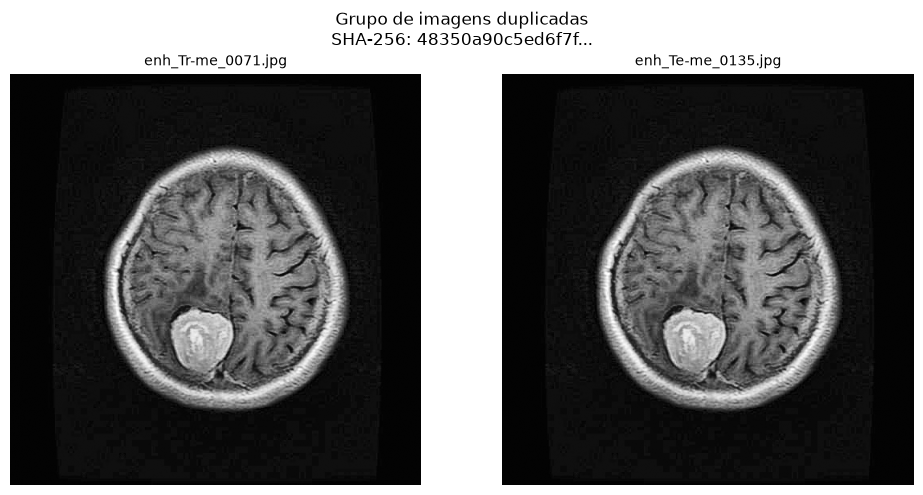

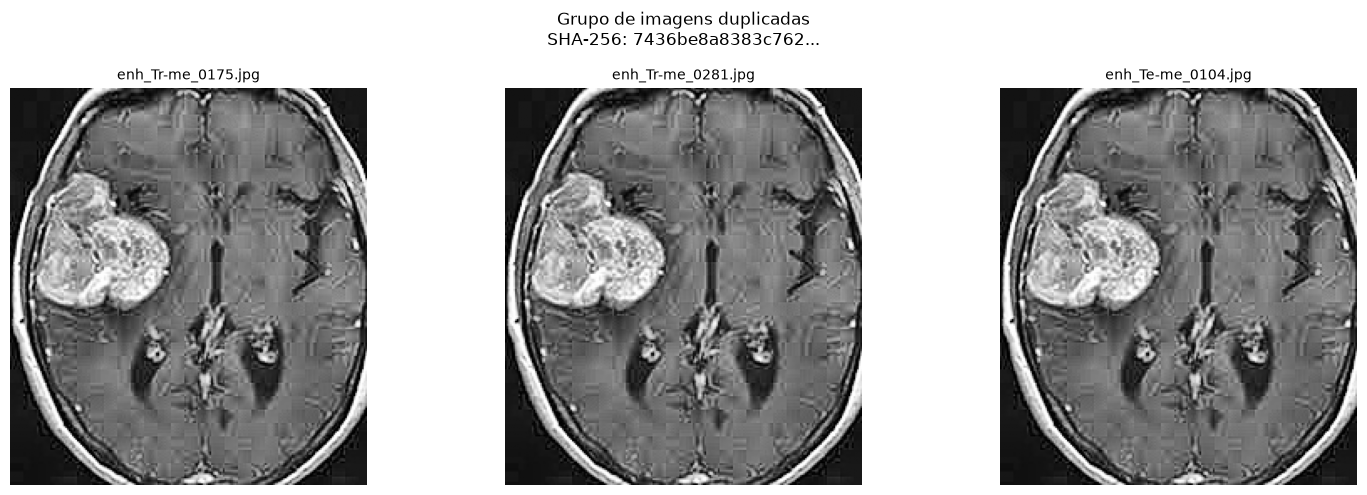

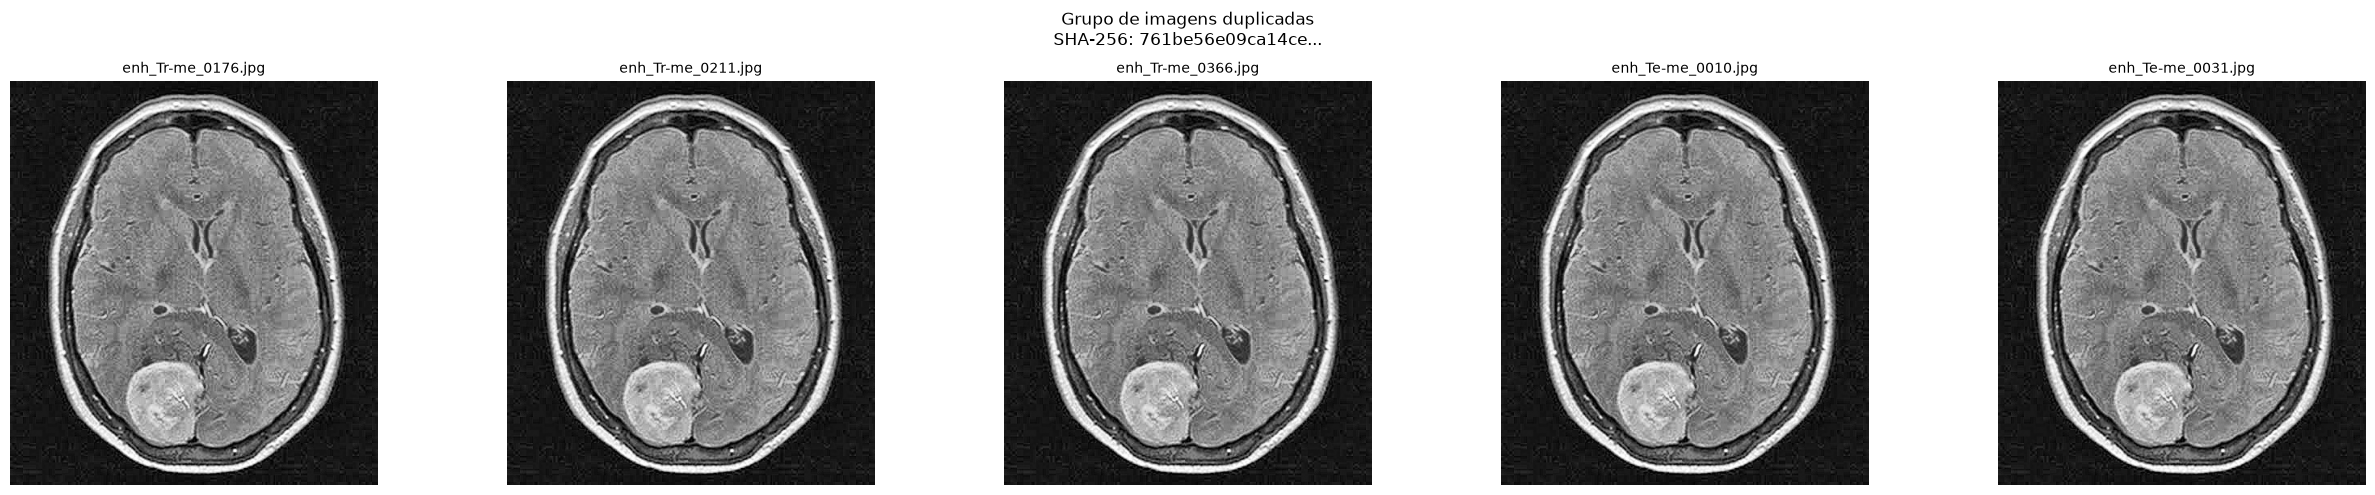

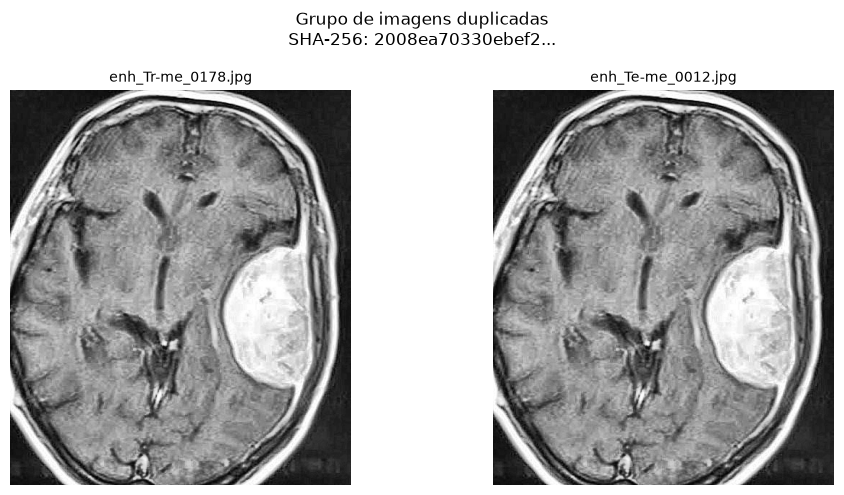

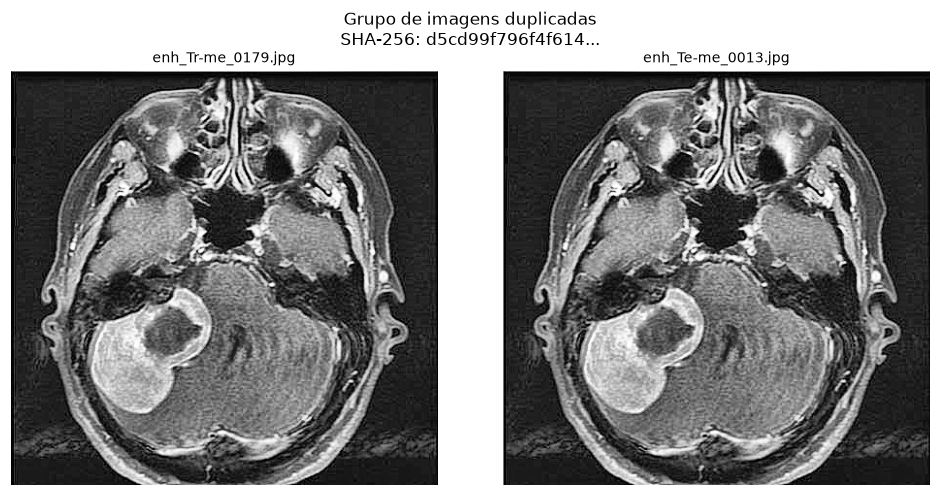

In [59]:
show_duplicate_examples(
    duplicate_groups,
    max_groups=5
)

## 13. Verificação de data leakage entre Training e Testing

Uma preocupação importante em problemas de Machine Learning é a possibilidade de existirem exactamente as mesmas imagens nos conjuntos de treinamento e teste.

Caso isso aconteça, o modelo poderá ser avaliado utilizando imagens que já foram utilizadas durante o treinamento, produzindo resultados artificialmente optimistas.

Por isso, será verificada a existência de ficheiros binariamente idênticos entre os dois conjuntos.

In [60]:
train_hashes = set(
    metadata_df.loc[
        metadata_df["split"] == "Training",
        "sha256"
    ].dropna()
)

test_hashes = set(
    metadata_df.loc[
        metadata_df["split"] == "Testing",
        "sha256"
    ].dropna()
)

overlap = train_hashes.intersection(
    test_hashes
)

print(
    f"Imagens exactamente iguais entre Training e Testing: "
    f"{len(overlap)}"
)

Imagens exactamente iguais entre Training e Testing: 189


In [63]:
if overlap:

    leakage_images = metadata_df[
        metadata_df["sha256"].isin(overlap)
    ].sort_values("sha256")

    print(
        f"Foram encontradas {len(overlap)} "
        f"imagens binariamente idênticas entre "
        f"Training e Testing."
    )

    display(
        leakage_images[
            [
                "split",
                "class",
                "path",
                "sha256"
            ]
        ]
    )

else:

    print(
        "Não foram encontradas imagens binariamente "
        "idênticas entre Training e Testing."
    )

Foram encontradas 189 imagens binariamente idênticas entre Training e Testing.


,split,class,path,sha256
6091,Testing,meningioma,..\dataset\classification\Testing\meningioma\e...,0093201c8044b1c03b5bb42b5821f7971993636de9812c...
1578,Training,meningioma,..\dataset\classification\Training\meningioma\...,0093201c8044b1c03b5bb42b5821f7971993636de9812c...
1526,Training,meningioma,..\dataset\classification\Training\meningioma\...,0251f686d9018d509ff9c0446e686217e71ad39337a941...
6037,Testing,meningioma,..\dataset\classification\Testing\meningioma\e...,0251f686d9018d509ff9c0446e686217e71ad39337a941...
6422,Testing,notumor,..\dataset\classification\Testing\notumor\enh_...,03e1d61309cf9a1fbbe09b44440484f0966bb748e63182...
...,...,...,...,...
3754,Training,notumor,..\dataset\classification\Training\notumor\enh...,ff1301a41a4b9d16a2328d836df3adf42dcfe222ce89c7...
1558,Training,meningioma,..\dataset\classification\Training\meningioma\...,ff31b1c0a364025881d7a18e07bcd3b5a61e49ab89613e...
6070,Testing,meningioma,..\dataset\classification\Testing\meningioma\e...,ff31b1c0a364025881d7a18e07bcd3b5a61e49ab89613e...
2806,Training,notumor,..\dataset\classification\Training\notumor\enh...,ff33c4c7300aec02e6062a8922cffb397fbbb2ce5ff396...


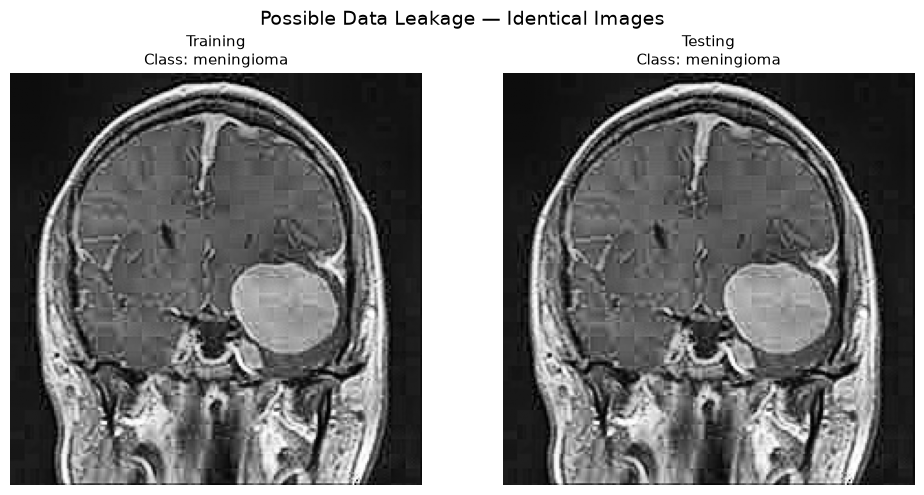

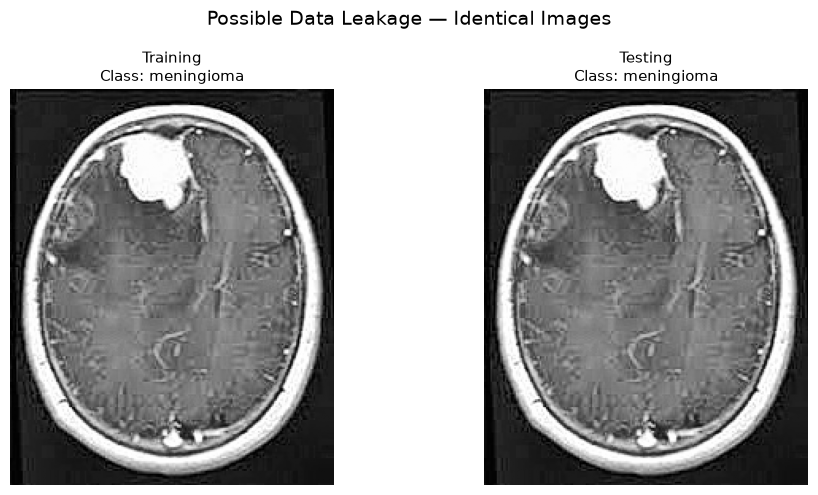

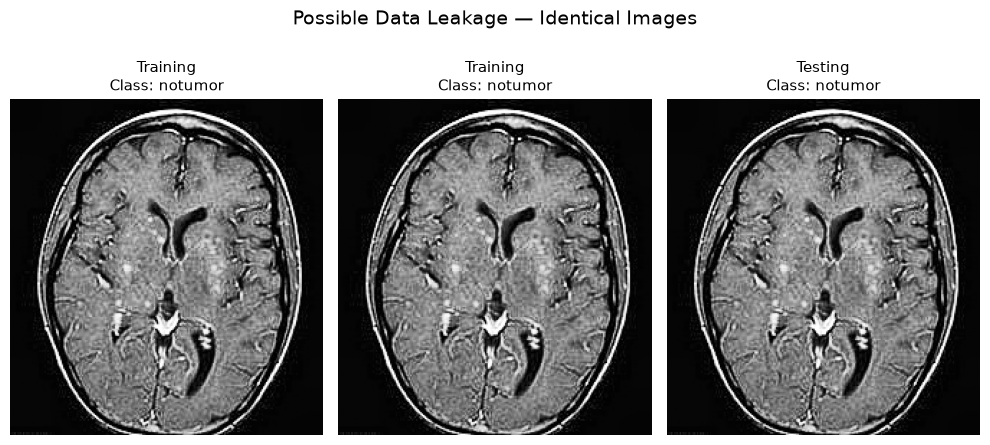

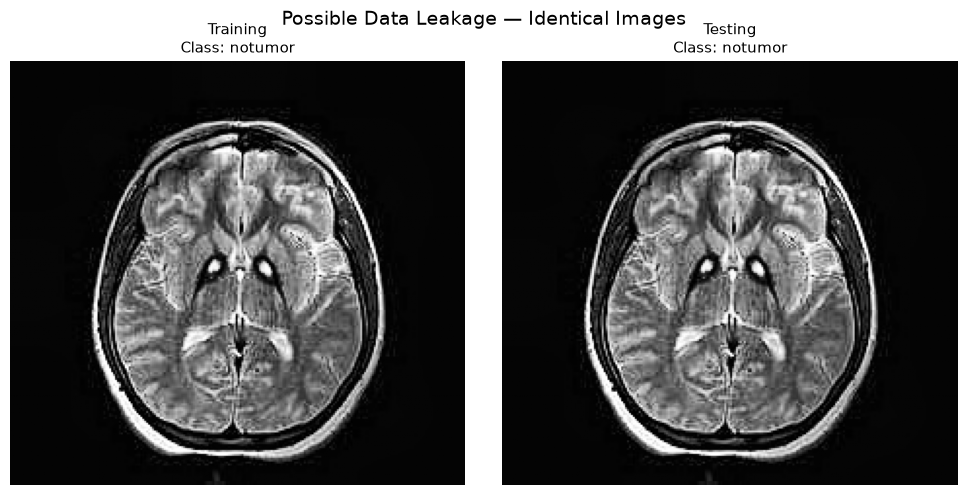

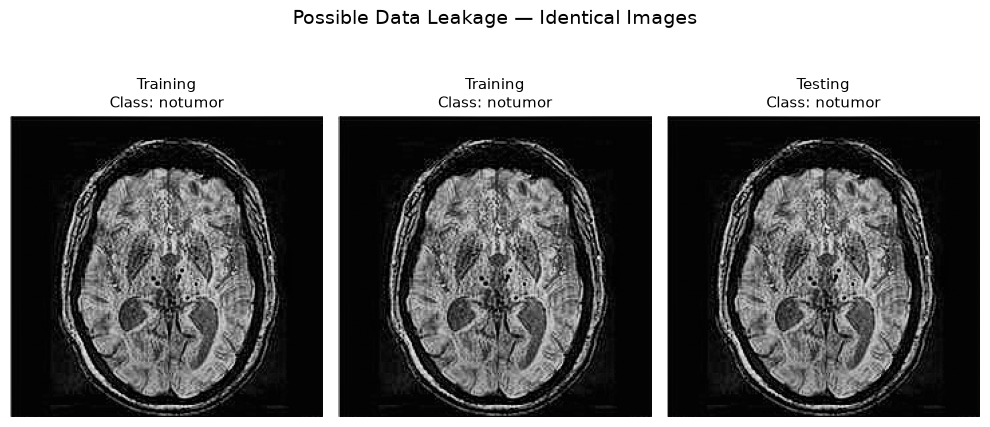

In [64]:
if overlap:

    max_groups = 5

    for hash_value in list(overlap)[:max_groups]:

        group = metadata_df[
            metadata_df["sha256"] == hash_value
        ]

        fig, axes = plt.subplots(
            1,
            len(group),
            figsize=(10, 5)
        )

        axes = np.atleast_1d(axes)

        for ax, (_, row) in zip(
            axes,
            group.iterrows()
        ):

            with Image.open(row["path"]) as image:
                ax.imshow(
                    image,
                    cmap="gray"
                )

            ax.set_title(
                f'{row["split"]}\n'
                f'Class: {row["class"]}',
                fontsize=11
            )

            ax.axis("off")

        plt.suptitle(
            "Possible Data Leakage — Identical Images",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()

else:

    print(
        "Não existem imagens para visualizar, "
        "pois não foi detectada sobreposição."
    )

## 14. Resumo da Análise Exploratória

Nesta secção são apresentados os principais resultados quantitativos obtidos durante a EDA.

In [65]:
summary = pd.DataFrame(
    {
        "Metric": [
            "Total de imagens",
            "Imagens de Training",
            "Imagens de Testing",
            "Número de classes",
            "Imagens válidas",
            "Imagens inválidas",
            "Dimensões únicas",
            "Duplicados exactos",
            "Sobreposição Training/Testing"
        ],
        "Value": [
            len(metadata_df),
            total_train,
            total_test,
            len(class_names),
            int(metadata_df["valid"].sum()),
            int((~metadata_df["valid"]).sum()),
            valid_metadata[
                ["width", "height"]
            ].drop_duplicates().shape[0],
            len(duplicate_groups),
            len(overlap)
        ]
    }
)

summary

,Metric,Value
0,Total de imagens,7023
1,Imagens de Training,5712
2,Imagens de Testing,1311
3,Número de classes,4
4,Imagens válidas,7023
5,Imagens inválidas,0
6,Dimensões únicas,387
7,Duplicados exactos,726
8,Sobreposição Training/Testing,189
